# 1 EDA (Exploratory Data Analysis)

In [2]:
# import libararys 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_excel("Dataset for Data Analytics.xlsx")
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(

In [5]:
df.describe()

,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000
std,NaN,1.407557,197.177146,2.281983,819.856558


In [6]:
df.shape

(1200, 14)

In [7]:
df.isnull().sum()

OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

In [8]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
1195    False
1196    False
1197    False
1198    False
1199    False
Length: 1200, dtype: bool

In [9]:
# drope columns that are not needed for analysis
df = df.drop(columns=['CustomerID', 'OrderID', 'TrackingNumber'])

In [10]:
# fix date column

df['Date'] = pd.to_datetime(df['Date'])


In [11]:
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['weekday'] = df['Date'].dt.weekday
df['Year'] = df['Date'].dt.year

df = df.drop(columns=['Date'])
df.head()

,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,ItemsInCart,CouponCode,ReferralSource,TotalPrice,Month,Day,weekday,Year
0,Monitor,5,570.62,928 Main St,Debit Card,Shipped,7,SAVE10,Instagram,2853.10,1,4,2,2023
1,Phone,2,151.35,823 Main St,Online,Shipped,3,SAVE10,Referral,302.70,8,23,4,2024
2,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,8,FREESHIP,Email,2753.40,2,27,1,2024
3,Chair,1,273.19,275 Main St,Debit Card,Returned,5,SAVE10,Facebook,273.19,10,15,6,2023
4,Printer,4,626.01,668 Main St,Online,Delivered,8,SAVE10,Email,2504.04,5,8,3,2025


In [12]:
#  2. Drop Low-Value Column
# Too many unique values → not useful
df = df.drop(columns=['ShippingAddress'])
df.head()

,Product,Quantity,UnitPrice,PaymentMethod,OrderStatus,ItemsInCart,CouponCode,ReferralSource,TotalPrice,Month,Day,weekday,Year
0,Monitor,5,570.62,Debit Card,Shipped,7,SAVE10,Instagram,2853.10,1,4,2,2023
1,Phone,2,151.35,Online,Shipped,3,SAVE10,Referral,302.70,8,23,4,2024
2,Tablet,5,550.68,Credit Card,Cancelled,8,FREESHIP,Email,2753.40,2,27,1,2024
3,Chair,1,273.19,Debit Card,Returned,5,SAVE10,Facebook,273.19,10,15,6,2023
4,Printer,4,626.01,Online,Delivered,8,SAVE10,Email,2504.04,5,8,3,2025


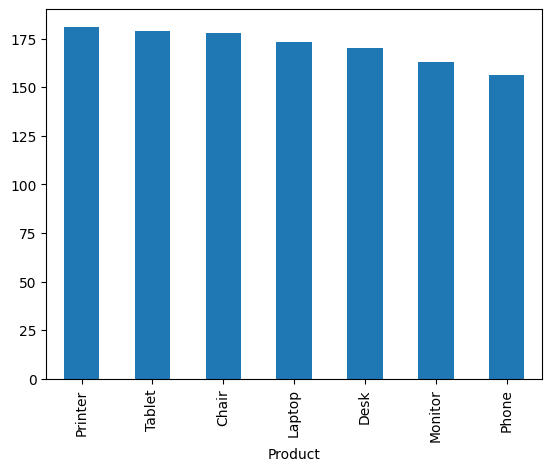

In [13]:
# Top Selling Products
df['Product'].value_counts().plot(kind='bar')
plt.show()

<Axes: xlabel='Product'>

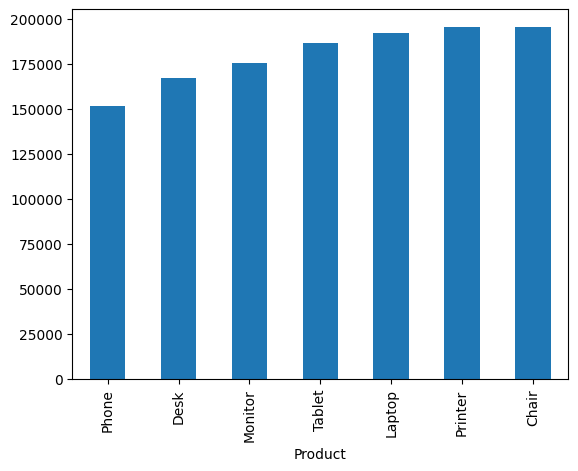

In [14]:
# Revenue by Product
df.groupby("Product")['TotalPrice'].sum().sort_values().plot(kind='bar')

<Axes: xlabel='Month'>

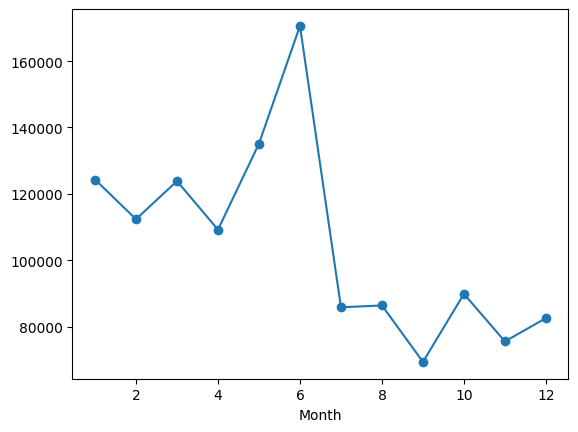

In [15]:
# Sales Over Time
df.groupby("Month")['TotalPrice'].sum().plot(kind='line', marker='o')

<Axes: ylabel='count'>

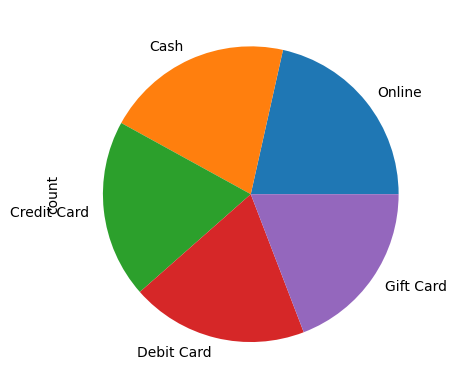

In [16]:
# Payment Method Usage
df['PaymentMethod'].value_counts().plot(kind='pie')

In [17]:
# check values
df['OrderStatus'].value_counts()

OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64

In [18]:
# covert OrderStatus to binary 1 = success, 0 = Problematic
df['OrderStatus'] = df['OrderStatus'].apply(lambda x: 1 if x == 'Delivered' else 0)

In [19]:
df.head(10)

,Product,Quantity,UnitPrice,PaymentMethod,OrderStatus,ItemsInCart,CouponCode,ReferralSource,TotalPrice,Month,Day,weekday,Year
0,Monitor,5,570.62,Debit Card,0,7,SAVE10,Instagram,2853.10,1,4,2,2023
1,Phone,2,151.35,Online,0,3,SAVE10,Referral,302.70,8,23,4,2024
2,Tablet,5,550.68,Credit Card,0,8,FREESHIP,Email,2753.40,2,27,1,2024
3,Chair,1,273.19,Debit Card,0,5,SAVE10,Facebook,273.19,10,15,6,2023
4,Printer,4,626.01,Online,1,8,SAVE10,Email,2504.04,5,8,3,2025
5,Phone,2,245.86,Credit Card,0,4,SAVE10,Instagram,491.72,10,23,0,2023
6,Laptop,1,664.42,Gift Card,0,6,SAVE10,Facebook,664.42,6,17,1,2025
7,Monitor,5,149.55,Cash,0,9,FREESHIP,Facebook,747.75,5,12,4,2023
8,Phone,2,134.28,Gift Card,0,2,NaN,Email,268.56,4,2,2,2025
9,Desk,4,509.38,Credit Card,0,6,SAVE10,Google,2037.52,11,21,1,2023


In [20]:
df = pd.get_dummies(df, drop_first=True)

In [21]:
#  now check Missing values agian
df.isnull().sum()

Quantity                     0
UnitPrice                    0
OrderStatus                  0
ItemsInCart                  0
TotalPrice                   0
Month                        0
Day                          0
weekday                      0
Year                         0
Product_Desk                 0
Product_Laptop               0
Product_Monitor              0
Product_Phone                0
Product_Printer              0
Product_Tablet               0
PaymentMethod_Credit Card    0
PaymentMethod_Debit Card     0
PaymentMethod_Gift Card      0
PaymentMethod_Online         0
CouponCode_SAVE10            0
CouponCode_WINTER15          0
ReferralSource_Facebook      0
ReferralSource_Google        0
ReferralSource_Instagram     0
ReferralSource_Referral      0
dtype: int64

In [22]:
df.duplicated().sum()
df.head(10)

,Quantity,UnitPrice,OrderStatus,ItemsInCart,TotalPrice,Month,Day,weekday,Year,Product_Desk,...,PaymentMethod_Credit Card,PaymentMethod_Debit Card,PaymentMethod_Gift Card,PaymentMethod_Online,CouponCode_SAVE10,CouponCode_WINTER15,ReferralSource_Facebook,ReferralSource_Google,ReferralSource_Instagram,ReferralSource_Referral
0,5,570.62,0,7,2853.10,1,4,2,2023,False,...,False,True,False,False,True,False,False,False,True,False
1,2,151.35,0,3,302.70,8,23,4,2024,False,...,False,False,False,True,True,False,False,False,False,True
2,5,550.68,0,8,2753.40,2,27,1,2024,False,...,True,False,False,False,False,False,False,False,False,False
3,1,273.19,0,5,273.19,10,15,6,2023,False,...,False,True,False,False,True,False,True,False,False,False
4,4,626.01,1,8,2504.04,5,8,3,2025,False,...,False,False,False,True,True,False,False,False,False,False
5,2,245.86,0,4,491.72,10,23,0,2023,False,...,True,False,False,False,True,False,False,False,True,False
6,1,664.42,0,6,664.42,6,17,1,2025,False,...,False,False,True,False,True,False,True,False,False,False
7,5,149.55,0,9,747.75,5,12,4,2023,False,...,False,False,False,False,False,False,True,False,False,False
8,2,134.28,0,2,268.56,4,2,2,2025,False,...,False,False,True,False,False,False,False,False,False,False
9,4,509.38,0,6,2037.52,11,21,1,2023,True,...,True,False,False,False,True,False,False,True,False,False


In [23]:
df = df.drop(columns=['TotalPrice'])

In [24]:
df = df.astype('int')

In [25]:
df = df.drop(columns=['Year'])

In [26]:
df = pd.get_dummies(df, drop_first=True)

In [27]:
df[['Quantity', 'ItemsInCart']].corr()

,Quantity,ItemsInCart
Quantity,1.000000,0.650061
ItemsInCart,0.650061,1.000000


In [28]:
df.head(10)

,Quantity,UnitPrice,OrderStatus,ItemsInCart,Month,Day,weekday,Product_Desk,Product_Laptop,Product_Monitor,...,PaymentMethod_Credit Card,PaymentMethod_Debit Card,PaymentMethod_Gift Card,PaymentMethod_Online,CouponCode_SAVE10,CouponCode_WINTER15,ReferralSource_Facebook,ReferralSource_Google,ReferralSource_Instagram,ReferralSource_Referral
0,5,570,0,7,1,4,2,0,0,1,...,0,1,0,0,1,0,0,0,1,0
1,2,151,0,3,8,23,4,0,0,0,...,0,0,0,1,1,0,0,0,0,1
2,5,550,0,8,2,27,1,0,0,0,...,1,0,0,0,0,0,0,0,0,0
3,1,273,0,5,10,15,6,0,0,0,...,0,1,0,0,1,0,1,0,0,0
4,4,626,1,8,5,8,3,0,0,0,...,0,0,0,1,1,0,0,0,0,0
5,2,245,0,4,10,23,0,0,0,0,...,1,0,0,0,1,0,0,0,1,0
6,1,664,0,6,6,17,1,0,1,0,...,0,0,1,0,1,0,1,0,0,0
7,5,149,0,9,5,12,4,0,0,1,...,0,0,0,0,0,0,1,0,0,0
8,2,134,0,2,4,2,2,0,0,0,...,0,0,1,0,0,0,0,0,0,0
9,4,509,0,6,11,21,1,1,0,0,...,1,0,0,0,1,0,0,1,0,0


In [29]:
# Clean all column names
import re

df.columns = (
    df.columns
    .str.strip()                         # remove extra spaces
    .str.lower()                         # lowercase
    .str.replace(" ", "_")               # spaces → underscore
    .str.replace(r"[^\w]", "", regex=True)  # remove special chars
)

In [30]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(r"[^\w\s]", "", regex=True)  # remove symbols but keep spaces
    .str.replace(r"\s+", "_", regex=True)     # spaces → underscore
)

In [31]:
df.head()

,quantity,unitprice,orderstatus,itemsincart,month,day,weekday,product_desk,product_laptop,product_monitor,...,paymentmethod_credit_card,paymentmethod_debit_card,paymentmethod_gift_card,paymentmethod_online,couponcode_save10,couponcode_winter15,referralsource_facebook,referralsource_google,referralsource_instagram,referralsource_referral
0,5,570,0,7,1,4,2,0,0,1,...,0,1,0,0,1,0,0,0,1,0
1,2,151,0,3,8,23,4,0,0,0,...,0,0,0,1,1,0,0,0,0,1
2,5,550,0,8,2,27,1,0,0,0,...,1,0,0,0,0,0,0,0,0,0
3,1,273,0,5,10,15,6,0,0,0,...,0,1,0,0,1,0,1,0,0,0
4,4,626,1,8,5,8,3,0,0,0,...,0,0,0,1,1,0,0,0,0,0


------

In [32]:
df['target'] = (df['quantity'] >= 3).astype(int)

X = df.drop(columns=['target', 'quantity'])
y = df['target']

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7041666666666667
              precision    recall  f1-score   support

           0       0.66      0.59      0.62        99
           1       0.73      0.79      0.76       141

    accuracy                           0.70       240
   macro avg       0.69      0.69      0.69       240
weighted avg       0.70      0.70      0.70       240



In [35]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

In [37]:
# Separate features and target
X = df.drop(columns=['target', 'quantity'])

y = df['target']

In [38]:
# Train / test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [39]:
# Model 1 — Random Forest (your current model)
rf = RandomForestClassifier(n_estimators=200, random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.7041666666666667
              precision    recall  f1-score   support

           0       0.66      0.59      0.62        99
           1       0.73      0.79      0.76       141

    accuracy                           0.70       240
   macro avg       0.69      0.69      0.69       240
weighted avg       0.70      0.70      0.70       240



In [42]:
# Model 2 — Gradient Boosting (often slightly better)

gb = GradientBoostingClassifier(n_estimators=200, random_state=42)

gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)

print("Gradient Boost Accuracy:", accuracy_score(y_test, gb_pred))

Gradient Boost Accuracy: 0.7


In [44]:
# Model 3 — Logistic Regression (needs scaling)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, random_state=42)

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy: 0.7083333333333334


In [45]:
# Cross validation — more reliable than single test score


cv = cross_val_score(rf, X, y, cv=5, scoring='accuracy')

print(f"CV Accuracy: {cv.mean():.4f} +/- {cv.std():.4f}")


CV Accuracy: 0.6917 +/- 0.0236
